# Hyperparameter Sweep: Vanilla RNN vs LSTM

Systematic comparison of model architectures and hyperparameters across both
**behavior prediction** (choice) and **neural prediction** (PSTH) tasks.

Results are logged to separate files:
- `results/sweep_results_vanilla_rnn.csv`
- `results/sweep_results_lstm.csv`

Each row is tagged with session metadata (`animal_name`, `session_date`) and
architecture labels for easier filtering and recovery.

---

### Running on GCP

1. **Clone the repo** onto your VM:
   ```bash
   git clone https://github.com/stellinaao/df-rnns.git && cd df-rnns
   ```
2. **Create a conda env** and install dependencies:
   ```bash
   conda create -n dfrnns python=3.12 -y && conda activate dfrnns
   pip install -r requirements-gcp.txt
   ```
3. **Upload data** (scp or gcloud):
   ```bash
   # Copy the NP analysis data folder to the VM
   scp -r /path/to/DynamicForagingNPanalysis/data user@<VM_IP>:~/data
   ```
4. **Set the `DATA_ROOT` env var** before launching the notebook:
   ```bash
   export DATA_ROOT=~/data
   ```
5. **Launch JupyterLab** (or use VS Code Remote-SSH):
   ```bash
   jupyter lab --no-browser --port=8888
   ```
   Then SSH-tunnel to your VM: `ssh -L 8888:localhost:8888 user@<VM_IP>`

6. **Use tmux** so long-running sweeps survive SSH disconnects:
   ```bash
   tmux new -s sweep
   jupyter lab --no-browser --port=8888
   # Ctrl-b d to detach; tmux a -t sweep to re-attach
   ```

## 1. Imports and Setup

In [1]:
import os
import random
import importlib
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Add repo/src to sys.path
try:
    _nb_dir = Path(__file__).resolve().parent
except NameError:
    _nb_dir = Path.cwd()

for _candidate in [_nb_dir, _nb_dir.parent]:
    _src = _candidate / "src"
    if _src.exists():
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break

from rnn_utils import (
    create_neural_targets_from_psth,
    align_behavior_and_neural,
)
from data_io import vectorize_labels

import sweep as sweep_mod
importlib.reload(sweep_mod)
generate_search_configs = sweep_mod.generate_search_configs
generate_refined_search_configs = getattr(sweep_mod, "generate_refined_search_configs", None)
run_sweep = sweep_mod.run_sweep

from sweep_viz import (
    plot_best_per_architecture,
    plot_training_curves_comparison,
    plot_metric_distribution,
    plot_hp_importance,
    plot_hp_heatmap,
    plot_sweep_parallel_coords,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)

Using device: cuda


## 2. Load Data

### 2a. Behavioral Data

In [2]:
DATA_ROOT = Path(os.environ.get("DATA_ROOT", "/Users/lsye/DynamicForagingNPanalysis/data"))
ANIMAL  = "MM012"
SESSION = "20231211_172819"
SESSION_DIR    = DATA_ROOT / ANIMAL / SESSION
TRIALDATA_PATH = SESSION_DIR / "trialdata.csv"

trialdata    = pd.read_csv(TRIALDATA_PATH)
session_data = {"MFblocks": [], "MBblocks": []}

prev_action_left  = vectorize_labels(trialdata, session_data, "prev_choice_left",  rewarded_only=False)
prev_action_right = vectorize_labels(trialdata, session_data, "prev_choice_right", rewarded_only=False)
prev_reward       = vectorize_labels(trialdata, session_data, "prev_reward",        rewarded_only=False)
trial_start       = vectorize_labels(trialdata, session_data, "trial_start",        rewarded_only=False)

y_real = vectorize_labels(trialdata, session_data, "choice", rewarded_only=False).astype(np.int64)

X_real = np.column_stack([
    prev_action_left,
    prev_action_right,
    prev_reward,
    trial_start,
]).astype(np.float32)

X_behav_torch = torch.tensor(X_real, dtype=torch.float32, device=DEVICE).unsqueeze(0)
Y_behav_torch = torch.tensor(y_real, dtype=torch.long,    device=DEVICE).unsqueeze(0)

print(f"Behavioral data: X={tuple(X_behav_torch.shape)}, Y={tuple(Y_behav_torch.shape)}")
print(f"Right-choice fraction: {y_real.mean():.3f}")
print("(Only used if 'behavior' is in RUN_TASKS)")

Behavioral data: X=(1, 337, 4), Y=(1, 337)
Right-choice fraction: 0.531
(Only used if 'behavior' is in RUN_TASKS)


### 2b. Neural Data

In [5]:
neural_targets_dict, neural_meta = create_neural_targets_from_psth(
    animal_name=ANIMAL,
    session=SESSION,
    data_root=str(DATA_ROOT),
    trial_period="choice",
    rewarded_only=False,
    probes=("imec0", "imec1"),
    binwidth_ms=100,
    tpre=1,
    tpost=2,
)

TARGET_KEY = next(iter(neural_targets_dict))
print("Available targets:", list(neural_targets_dict.keys()))
print("Using:", TARGET_KEY, "| shape:", neural_targets_dict[TARGET_KEY].shape)

# Load dmat regressors
_repo = _nb_dir.parent  # repo root (notebooks/ -> repo)
for _c in [_nb_dir.parent, _nb_dir, Path.cwd(), Path.cwd().parent]:
    if (_c / "data" / "dmat-early.npz").exists():
        _repo = _c
        break
DMAT_PATH = _repo / "data" / "dmat-early.npz"

dmat_data = np.load(DMAT_PATH)
X_dmat = dmat_data["X"].astype(np.float32)

n_rows, n_regressors = X_dmat.shape
n_bins_per_trial = 299
n_trials_dmat = n_rows // n_bins_per_trial
n_bins_total = n_trials_dmat * n_bins_per_trial
X_dmat_reshaped = X_dmat[:n_bins_total].reshape(n_trials_dmat, n_bins_per_trial, n_regressors)
X_neural_behavior = X_dmat_reshaped.mean(axis=1).astype(np.float32)

X_neural, Y_neural = align_behavior_and_neural(
    X_neural_behavior, neural_targets_dict[TARGET_KEY]
)

X_neural_torch = torch.tensor(X_neural, dtype=torch.float32, device=DEVICE).unsqueeze(0)
Y_neural_torch = torch.tensor(Y_neural, dtype=torch.float32, device=DEVICE).unsqueeze(0)

print(f"Neural data: X={tuple(X_neural_torch.shape)}, Y={tuple(Y_neural_torch.shape)}")

imec0:ACC excluded 25 unit(s) with mean rate < 1.0 Hz
imec0:DMS excluded 13 unit(s) with mean rate < 1.0 Hz
imec1:M2 excluded 14 unit(s) with mean rate < 1.0 Hz
imec1:DLS excluded 16 unit(s) with mean rate < 1.0 Hz
Available targets: ['imec0_ACC', 'imec0_DMS', 'imec1_M2', 'imec1_DLS']
Using: imec0_ACC | shape: (337, 2128)
Neural data: X=(1, 336, 184), Y=(1, 336, 2128)


## 3. Configure Sweep

Set `RUN_TASKS` to control which tasks are swept.  Use `["neural"]` to run
only the neural prediction sweep, `["behavior"]` for only behavior, or
`["behavior", "neural"]` for both.

Adjust `MAX_CONFIGS` to trade off between thoroughness and runtime.

In [6]:
RUN_TASKS = ["neural"]  # ["behavior"], ["neural"], or ["behavior", "neural"]

MAX_CONFIGS = 20
PATIENCE = 200
RESULTS_DIR = _nb_dir.parent / "results"
RESULTS_DIR.mkdir(exist_ok=True)

RESULTS_CSV_BY_ARCH = {
    "vanilla_rnn": str(RESULTS_DIR / "sweep_results_vanilla_rnn.csv"),
    "lstm": str(RESULTS_DIR / "sweep_results_lstm.csv"),
}

# Sampling controls:
# - "random": uniform random subset from unseen configs
# - "refine": weighted random subset that favors hyperparameter values from top prior runs
SAMPLING_MODE = "random"
TOP_K_REFINE = 200
EXPLORE_FRACTION = 0.25

all_configs = []
SESSION_DATE = SESSION.split("_")[0] if "_" in SESSION else SESSION


def attach_session_metadata(configs, architecture):
    for cfg in configs:
        cfg["animal_name"] = ANIMAL
        cfg["session_date"] = SESSION_DATE
        cfg["architecture"] = architecture
    return configs


def make_configs(arch, task):
    csv_path = RESULTS_CSV_BY_ARCH[arch]
    if SAMPLING_MODE == "refine":
        if generate_refined_search_configs is None:
            print("Warning: generate_refined_search_configs not available; falling back to random deduped sampling.")
        else:
            return generate_refined_search_configs(
                model_type=arch,
                task_type=task,
                results_csv_paths=[csv_path],
                max_configs=MAX_CONFIGS,
                seed=SEED,
                top_k=TOP_K_REFINE,
                explore_frac=EXPLORE_FRACTION,
            )
    return generate_search_configs(
        model_type=arch,
        task_type=task,
        max_configs=MAX_CONFIGS,
        seed=SEED,
        exclude_csv_paths=[csv_path],
    )


if "behavior" in RUN_TASKS:
    configs_vanilla_behavior = attach_session_metadata(make_configs("vanilla_rnn", "behavior"), "vanilla_rnn")
    configs_lstm_behavior = attach_session_metadata(make_configs("lstm", "behavior"), "lstm")
    all_configs += configs_vanilla_behavior + configs_lstm_behavior
    print(f"Vanilla RNN behavior configs: {len(configs_vanilla_behavior)}")
    print(f"LSTM behavior configs:        {len(configs_lstm_behavior)}")
else:
    print("Skipping behavior configs (not in RUN_TASKS)")

if "neural" in RUN_TASKS:
    configs_vanilla_neural = attach_session_metadata(make_configs("vanilla_rnn", "neural"), "vanilla_rnn")
    configs_lstm_neural = attach_session_metadata(make_configs("lstm", "neural"), "lstm")
    all_configs += configs_vanilla_neural + configs_lstm_neural
    print(f"Vanilla RNN neural configs:   {len(configs_vanilla_neural)}")
    print(f"LSTM neural configs:          {len(configs_lstm_neural)}")
else:
    print("Skipping neural configs (not in RUN_TASKS)")

print(f"Total runs: {len(all_configs)}")
print("Sampling mode:", SAMPLING_MODE)
print("CSV outputs by architecture:", RESULTS_CSV_BY_ARCH)

Skipping behavior configs (not in RUN_TASKS)
Vanilla RNN neural configs:   20
LSTM neural configs:          20
Total runs: 40
Sampling mode: random
CSV outputs by architecture: {'vanilla_rnn': '/home/uclaletizia/df-rnns/results/sweep_results_vanilla_rnn.csv', 'lstm': '/home/uclaletizia/df-rnns/results/sweep_results_lstm.csv'}


## 4. Run Behavior Sweep

In [ ]:
if "behavior" in RUN_TASKS:
    df_behavior_vanilla = run_sweep(
        configs=configs_vanilla_behavior,
        X_train=X_behav_torch,
        Y_train=Y_behav_torch,
        input_size=X_behav_torch.shape[-1],
        output_size=2,
        device=DEVICE,
        results_csv=RESULTS_CSV_BY_ARCH["vanilla_rnn"],
        patience=PATIENCE,
        print_every=500,
    )

    df_behavior_lstm = run_sweep(
        configs=configs_lstm_behavior,
        X_train=X_behav_torch,
        Y_train=Y_behav_torch,
        input_size=X_behav_torch.shape[-1],
        output_size=2,
        device=DEVICE,
        results_csv=RESULTS_CSV_BY_ARCH["lstm"],
        patience=PATIENCE,
        print_every=500,
    )

    df_behavior = pd.concat([df_behavior_vanilla, df_behavior_lstm], ignore_index=True)
else:
    print("Skipping behavior sweep (not in RUN_TASKS)")

## 5. Run Neural Sweep

In [ ]:
if "neural" in RUN_TASKS:
    df_neural_vanilla = run_sweep(
        configs=configs_vanilla_neural,
        X_train=X_neural_torch,
        Y_train=Y_neural_torch,
        input_size=X_neural_torch.shape[-1],
        output_size=Y_neural_torch.shape[-1],
        device=DEVICE,
        results_csv=RESULTS_CSV_BY_ARCH["vanilla_rnn"],
        patience=PATIENCE,
        print_every=500,
    )

    df_neural_lstm = run_sweep(
        configs=configs_lstm_neural,
        X_train=X_neural_torch,
        Y_train=Y_neural_torch,
        input_size=X_neural_torch.shape[-1],
        output_size=Y_neural_torch.shape[-1],
        device=DEVICE,
        results_csv=RESULTS_CSV_BY_ARCH["lstm"],
        patience=PATIENCE,
        print_every=500,
    )

    df_neural = pd.concat([df_neural_vanilla, df_neural_lstm], ignore_index=True)
else:
    print("Skipping neural sweep (not in RUN_TASKS)")

## 6. Load and Explore Results

If you've already run the sweep, you can reload and combine results from the
architecture-specific CSV files.

In [2]:
from pathlib import Path

RESULTS_DIR = Path.cwd().resolve().parent / "results"  # if running from notebooks/
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_CSV_BY_ARCH = {
    "vanilla_rnn": str(RESULTS_DIR / "sweep_results_vanilla_rnn.csv"),
    "lstm": str(RESULTS_DIR / "sweep_results_lstm.csv"),
}

In [3]:
dfs = []
# Try RESULTS_CSV_BY_ARCH first (exact paths)
for arch, csv_path in RESULTS_CSV_BY_ARCH.items():
    if Path(csv_path).exists():
        df_arch = pd.read_csv(csv_path)
        if "architecture" not in df_arch.columns:
            df_arch["architecture"] = arch
        dfs.append(df_arch)

# If not found, search recursively for sweep_results_*.csv (e.g. in timecourse_early/, timecourse_late/)
if not dfs:
    for csv_path in sorted(Path(RESULTS_DIR).rglob("sweep_results_*.csv")):
        if "_OLD" in csv_path.name:
            continue  # Skip legacy backup files
        df_arch = pd.read_csv(csv_path)
        if "architecture" not in df_arch.columns:
            arch = "lstm" if "lstm" in csv_path.name else "vanilla_rnn"
            df_arch["architecture"] = arch
        dfs.append(df_arch)

if not dfs:
    raise FileNotFoundError(f"No sweep CSVs found in {RESULTS_DIR} (or subdirs like timecourse_early/, timecourse_late/)")

df_all = pd.concat(dfs, ignore_index=True)
print(f"Total sweep rows: {len(df_all)}")
print(f"Columns: {list(df_all.columns)}")
df_all.groupby(["model_type", "task_type"])["best_metric"].describe()

FileNotFoundError: No sweep CSVs found in /home/uclaletizia/df-rnns/results

## 7. Cross-Architecture Comparisons

### 7a. Best Metric per Architecture

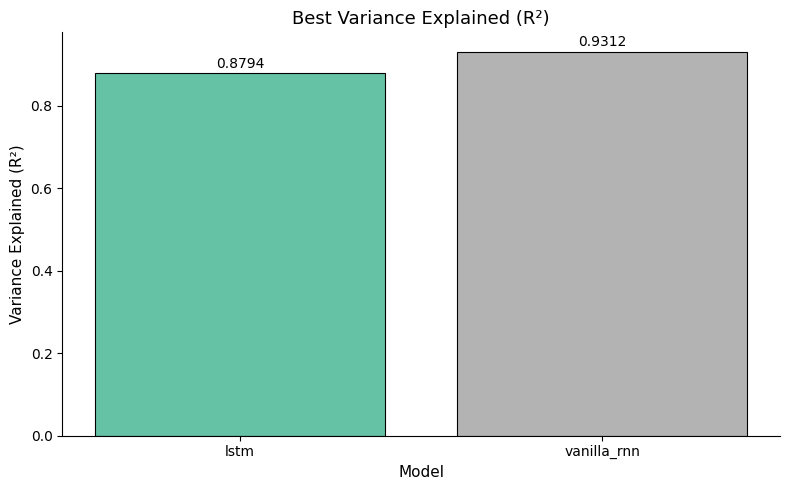

In [6]:
plot_best_per_architecture(df_all)

### 7b. Training Curves (Best Run per Architecture)

In [7]:
plot_training_curves_comparison(df_all, task_type="behavior")

No data to plot.


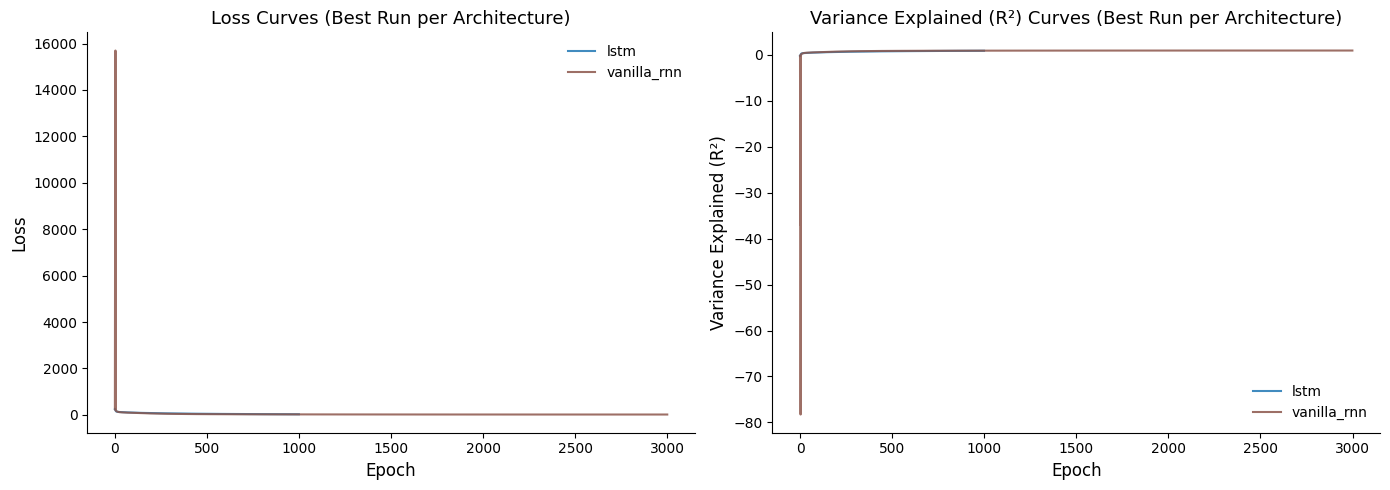

In [5]:
plot_training_curves_comparison(df_all, task_type="neural")

### 7c. Metric Distribution (Box Plot)

In [9]:
plot_metric_distribution(df_all, task_type="behavior")

No data to plot.


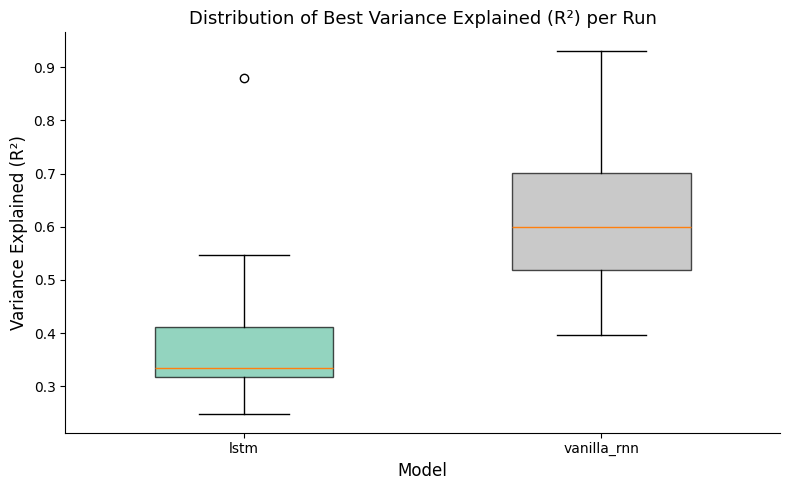

In [6]:
plot_metric_distribution(df_all, task_type="neural")

## 8. Per-Architecture HP Analysis

### 8a. HP Importance (Strip Plots)

In [11]:
plot_hp_importance(df_all, task_type="behavior")

No data to plot.


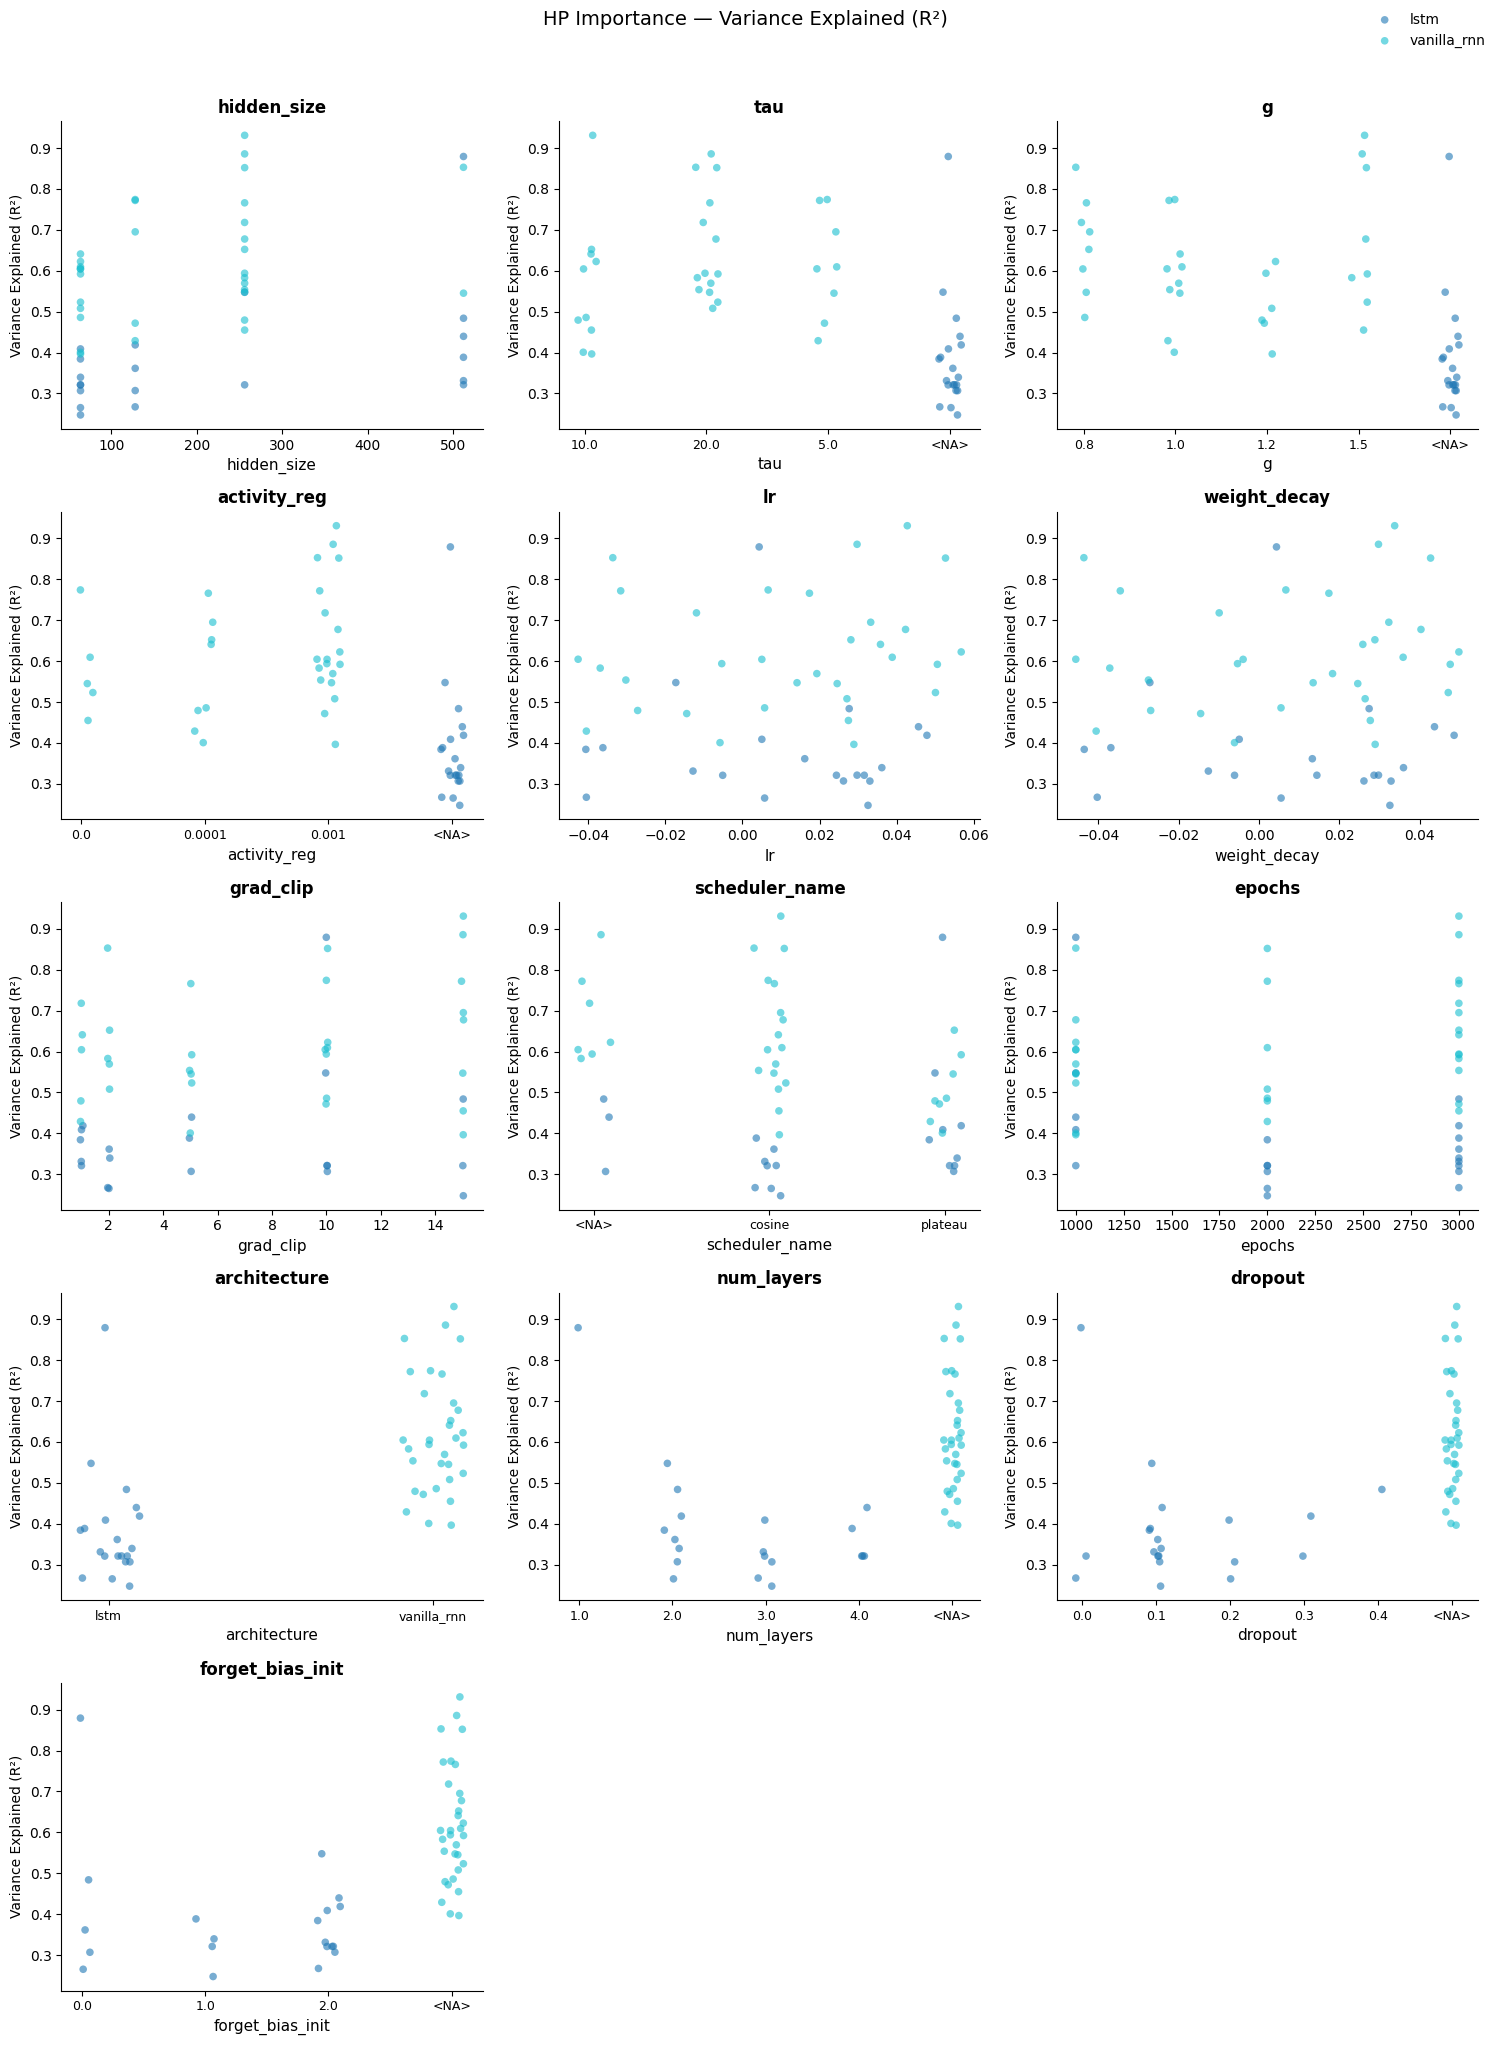

In [7]:
plot_hp_importance(df_all, task_type="neural")

### 8b. HP Heatmap (2D interaction)

Explore interactions between two HPs.  Adjust `hp_x` and `hp_y` to investigate
different combinations.

In [ ]:
plot_hp_heatmap(df_all, hp_x="hidden_size", hp_y="lr", task_type="behavior")

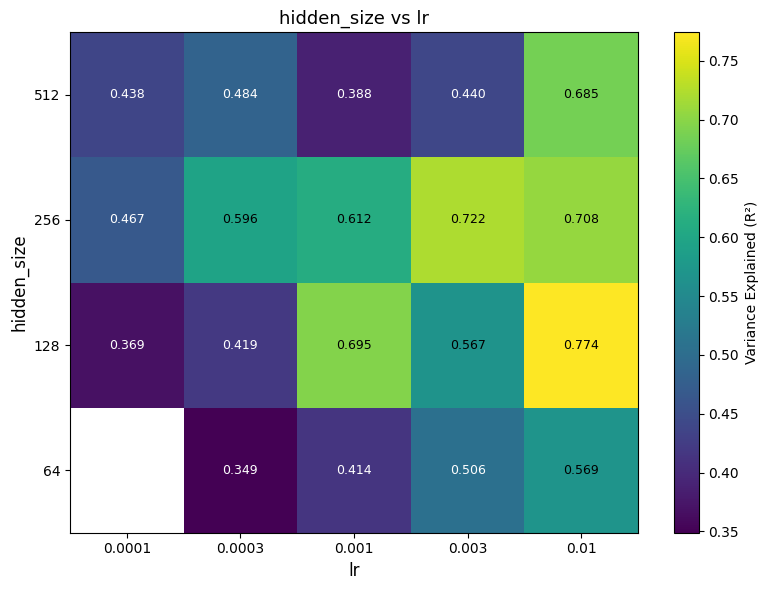

In [8]:
plot_hp_heatmap(df_all, hp_x="hidden_size", hp_y="lr", task_type="neural")


### 8c. Parallel Coordinates

In [ ]:
plot_sweep_parallel_coords(df_all, task_type="behavior", top_n=50)

In [14]:
plot_sweep_parallel_coords(df_all, task_type="neural", top_n=50)

TypeError: '<' not supported between instances of 'float' and 'str'

## 9. Summary

Display the top-5 configs for each task type.

In [1]:
for tt in df_all["task_type"].unique():
    print(f"\n{'='*80}")
    print(f"Top 5 runs for task_type = {tt}")
    print(f"{'='*80}")
    top5 = df_all[df_all["task_type"] == tt].nlargest(5, "best_metric")
    display_cols = [c for c in top5.columns if c not in ("loss_hist", "metric_hist", "timestamp")]
    display(top5[display_cols])

NameError: name 'df_all' is not defined